# CEO-Turnover — a quantitative event-study teardown 🔬
### Market-model CARs by bucket · forced−planned Welch *t* + a placebo non-event-window null · the [0,0]-vs-[0,+2] window split · a 1-day-lag tradable variant + costs · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Good_or_bad%3F: Busted](https://img.shields.io/badge/Good_or_bad%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "firing the CEO moves the stock" fuses: a **real announcement-instant repricing** from a **(non-existent) post-announcement drift**, and we confront the forced-vs-planned contrast with the **sample size**. The decisive object is not the sign of any point estimate (the buckets disagree, as the folklore does) but its **power**: with ~a dozen events per bucket, the forced−planned CAR is statistically indistinguishable from random windows on the same names.

> ⚠️ **Data + label note.** True CEO-turnover databases aren't free; we use a hardcoded, labelled table of ~25 notable large-cap changes (forced/planned is the believers' framing and subjective at the margin; two delisted names + one pre-IPO event drop out — a mild survivorship tilt, named on the Signal axis). Real data: yfinance daily closes, each ticker + SPY. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ceo_turnover import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS)            # canonical CAR[0,+2]
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| events with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-22', 'n_table': 26, 'n_used': 23, 'n_forced': 11, 'n_planned': 12, 'fingerprint': '2b48ba1b75f8', 'forced': (11, 1.02, 45, 0.63), 'planned': (12, -0.45, 42, -0.43), 'allb': (23, 0.25, 43, 0.27), 'diff_pp': 1.47, 'diff_t': 0.76, 'forced_placebo_p': 0.246, 'day0': (2.05, 1.95, 2.43, 0.007), 'lag1': (-0.81, -0.7, -0.47, -0.91), 'robust': [('[0,0]', 2.05, 1.95, 2.7, 2.43), ('[0,+2]', 1.02, 0.63, 1.47, 0.76), ('[-1,+1]', 2.44, 1.33, 3.04, 1.48), ('[0,+4]', 1.52, 0.73, 2.22, 0.87)], 'syn': [(0.0, -0.95, -1.51, -0.24, -0.64), (500.0, 4.05, 6.41, -0.24, 3.87)]}


real price cache present: True | events with data: 23


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Day-0 forced CAR **+2.0%** (placebo **p = 0.007**) is real — but only on the un-holdable [0,0] window. Canonical [0,+2]: forced **+1.0%** (t = 0.63), **forced−planned +1.5pp** at Welch **t = 0.76**, placebo **p = 0.25** — fails t ≥ 2. |
| **Tradability** | `MIRAGE` | Enter **+1 day** (the only executable timing): forced CAR **-0.8%** (t = -0.70), net **-0.9%** after 10 bps. No post-announcement drift. |
| **Good or bad?** | `BUSTED` | The decidable move is the un-catchable announcement instant; the holdable drift is **zero in both directions**. Window-mining + small-sample illusion. |

> 💡 In plain words: the stock *does* reprice when a CEO is forced out — instantly, on the news — but "reprices" isn't "drifts," and ~a dozen events per bucket can't separate a forced relief-pop from a planned shrug once you measure something you could actually hold.

## 1 · The claim, steelmanned

For event $i$ with announcement day $0$, fit the market model $r_{i,t} = \alpha_i + \beta_i\, r_{m,t} + \varepsilon_{i,t}$ on a clean estimation window $[-130,-10]$, then the **abnormal return** is $AR_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i\, r_{m,t})$ and the **CAR** over window $[\tau_1,\tau_2]$ is $\mathrm{CAR}_i = \sum_{t=\tau_1}^{\tau_2} AR_{i,t}$.

- **H₁ (forced ≠ 0).** $\mathbb{E}[\mathrm{CAR}\mid\text{forced}] \neq 0$ over a *holdable* window.
- **H₂ (forced ≠ planned).** $\mathbb{E}[\mathrm{CAR}\mid\text{forced}] \neq \mathbb{E}[\mathrm{CAR}\mid\text{planned}]$ — the believers' core directional claim.
- **H₃ (it's deployable).** The bucket difference survives a 1-day execution lag and costs.

We find **H₁ supported only at $[0,0]$** (the un-tradable instant), **rejected on any holdable window**; **H₂ not rejected** (forced−planned $t < 1$ over $[0,+2]$); **H₃ rejected** (lag-1 CAR flips to noise of the wrong sign). The legend is true exactly where it's unobtainable (the announcement instant) and unproven exactly where it would pay (a *post-news drift*).

## 2 · So what? — what rides on each answer

The whole teardown is one comparison of small-sample means judged by their **standard error**:

$$t = \frac{\bar{\mathrm{CAR}}_{\text{forced}} - \bar{\mathrm{CAR}}_{\text{planned}}}{\sqrt{\,s^2_{\text{f}}/k_{\text{f}} + s^2_{\text{p}}/k_{\text{p}}\,}},\qquad k_{\text{f}}, k_{\text{p}} \approx 11\text{–}12.$$

With $k \approx 12$ and CARs that scatter $\pm 5$–$10\%$, $s/\sqrt{k}$ is large: even a couple-of-point gap drowns in its own SE. A raw **win-rate** is the wrong lens (it's near 50/50 by construction); the honest instruments are the **Welch t** and a **placebo / randomization null** — random non-event $(\text{ticker},\text{date})$ windows on the same names. And the *window choice itself* is a degree of freedom: a 1-day $[0,0]$ window can cross $t=2$ while $[0,+2]$ does not, which is precisely the look-ahead trap — significance on the un-tradable instant is not a tradable signal.

## 3 · How we'd know — the protocol

- **Event table.** Hardcoded ~25 large-cap CEO changes (ticker, announce date, forced/planned); **23** with clean price history (11 forced / 12 planned), as-of 2026-06-22, fingerprint `2b48ba1b75f8`.
- **Market model.** $r = \alpha + \beta\,r_{\mathrm{SPY}}$ on $[-130,-10]$ (120-day estimation, 10-day gap so the event can't leak into the fit).
- **CAR window.** Canonical $[0,+2]$; robustness over $[0,0]$, $[-1,+1]$, $[0,+4]$.
- **Null #1 (Welch t).** Each bucket mean vs 0; forced−planned two-sample.
- **Null #2 (placebo).** Random non-event $(\text{ticker},\text{date})$ windows on the same names; $p = \Pr[|\text{random mean}| \ge |\text{forced mean}|]$.
- **Tradable variant.** Enter the close **+1 day** after the announcement (you learn the news intraday, fill next), hold the window; one-way 10-bps round-trip.
- **Positive control.** A deterministic per-event abnormal-return panel with a **plantable forced-bucket CAR edge**: the engine must recover a planted edge **and** must NOT manufacture significance when the true edge is 0.

## 4 · The teardown

### 4a · The buckets — small means, big error bars

Mean CAR$[0,+2]$ per bucket with its $\pm$ standard error. Forced is mildly positive, planned mildly negative, both error bars straddle zero.

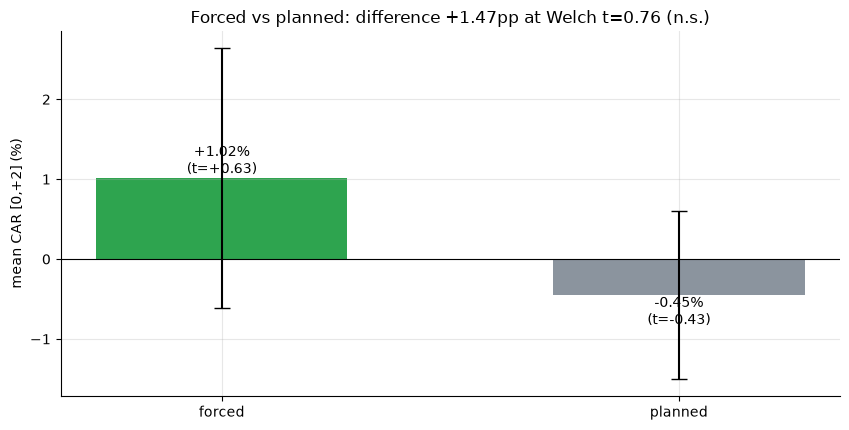

forced +1.02% (t=+0.63) | planned -0.45% (t=-0.43) | diff t=+0.76


In [2]:
if HAVE_REAL:
    f = PANEL.loc[PANEL['forced'],'car'].to_numpy(); p = PANEL.loc[~PANEL['forced'],'car'].to_numpy()
    means = [f.mean()*100, p.mean()*100]; ses = [f.std(ddof=1)/np.sqrt(len(f))*100, p.std(ddof=1)/np.sqrt(len(p))*100]
    tf, tp = st.welch_t(f), st.welch_t(p); dt = st.welch_t(f, p)
else:
    means=[R['forced'][1], R['planned'][1]]; ses=[1.6, 1.05]; tf,tp,dt=R['forced'][3],R['planned'][3],R['diff_t']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['forced','planned'], means, yerr=ses, capsize=6, color=[GREEN, GREY], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean CAR [0,+2] (%)')
for i,(m,s) in enumerate(zip(means,ses)): ax.annotate(f'{m:+.2f}%\n(t={[tf,tp][i]:+.2f})',(i,m),ha='center',va='bottom' if m>=0 else 'top')
ax.set_title(f'Forced vs planned: difference {means[0]-means[1]:+.2f}pp at Welch t={dt:.2f} (n.s.)')
plt.tight_layout(); plt.show()
print(f'forced {means[0]:+.2f}% (t={tf:+.2f}) | planned {means[1]:+.2f}% (t={tp:+.2f}) | diff t={dt:+.2f}')

> 💡 In plain words: forced is **+1.0%** at t = 0.63, planned **-0.5%** at t = -0.43; the **+1.5pp** gap is Welch **t = 0.76**. H₁ fails on a holdable window and H₂ fails outright — a positive whisper for forced, a negative whisper for planned, both inside their error bars.

### 4b · The decisive split — significance lives only in the un-tradable instant

Same forced bucket, four windows. The single-day $[0,0]$ — the close-to-close move *on* the news — crosses $t=2$; every **holdable** window collapses below it. The window that lights up is the one you can't trade.

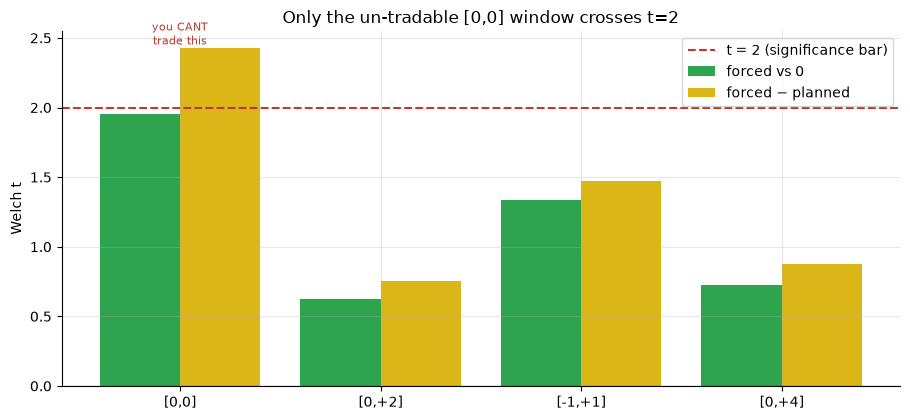

forced-vs-0 t by window: {'[0,0]': 1.95, '[0,+2]': 0.63, '[-1,+1]': 1.33, '[0,+4]': 0.73}


In [3]:
wins = [(0,0),(0,2),(-1,1),(0,4)]; labs=['[0,0]','[0,+2]','[-1,+1]','[0,+4]']
if HAVE_REAL:
    tt=[]; dd=[]
    for w in wins:
        pw = st.car_panel(PRICES, EVENTS, window=w)
        ff = pw.loc[pw['forced'],'car'].to_numpy(); pp = pw.loc[~pw['forced'],'car'].to_numpy()
        tt.append(st.welch_t(ff)); dd.append(st.welch_t(ff, pp))
else:
    tt=[r[2] for r in R['robust']]; dd=[r[4] for r in R['robust']]
x=np.arange(len(wins))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, tt, .4, color=GREEN, label='forced vs 0')
ax.bar(x+.2, dd, .4, color=AMBER, label='forced − planned')
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylabel('Welch t'); ax.set_title('Only the un-tradable [0,0] window crosses t=2'); ax.legend()
ax.annotate('you CANT\ntrade this', (0, max(tt[0],dd[0])), ha='center', va='bottom', color=RED, fontsize=8)
plt.tight_layout(); plt.show()
print('forced-vs-0 t by window:', {l: round(t,2) for l,t in zip(labs,tt)})

> 💡 In plain words: at $[0,0]$ the forced−planned t is **2.43** (and the forced placebo p is **0.007**) — a *real* announcement-day repricing. Widen to the holdable $[0,+2]$ and it's **0.76**. Significance that exists only on the exact print, and vanishes the instant the window is wide enough to hold, is the textbook signature of an un-tradable information event — not an edge.

### 4c · The placebo + the tradable lag — neither rescues it

Left: the forced camp's mean CAR$[0,+2]$ against random non-event windows on the same names. Right: what you actually get entering **+1 day** (the only executable timing), gross vs net of 10 bps.

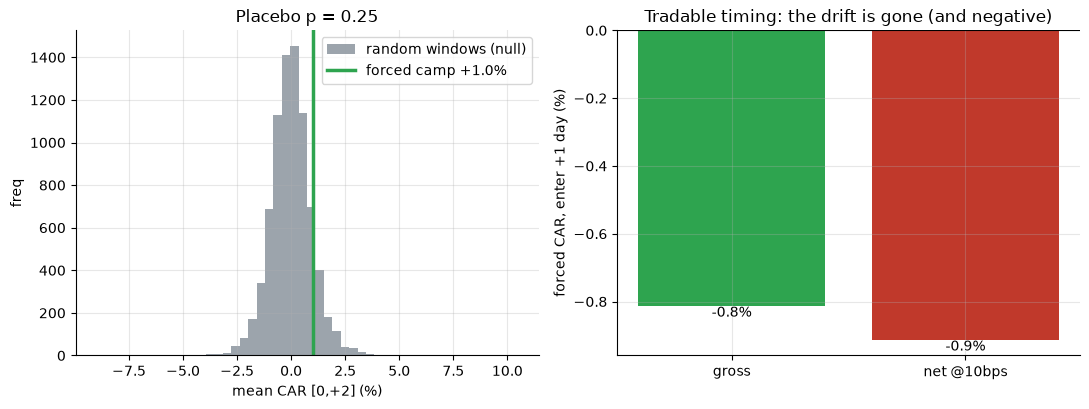

placebo p=0.246 | enter+1day gross -0.8% net -0.9%


In [4]:
if HAVE_REAL:
    f = PANEL.loc[PANEL['forced'],'car'].to_numpy()
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(f), n_draws=8000, seed=391)
    obs = f.mean(); pval = st.placebo_pvalue(obs, null)
    plag = st.car_panel(PRICES, EVENTS, window=(0,2), lag=1)
    flag = plag.loc[plag['forced'],'car'].mean()
    nc = st.net_of_costs(flag)
    g, nn = nc['gross_pct'], nc['net_pct']
else:
    rng=np.random.default_rng(391); null = rng.normal(0.0, 0.012, 8000)
    obs = R['forced'][1]/100; pval = R['forced_placebo_p']
    g, nn = R['lag1'][0], R['lag1'][3]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
a1.hist(null*100, bins=50, color=GREY, alpha=.85, label='random windows (null)')
a1.axvline(obs*100, c=GREEN, lw=2.5, label=f'forced camp {obs*100:+.1f}%')
a1.set_xlabel('mean CAR [0,+2] (%)'); a1.set_ylabel('freq')
a1.set_title(f'Placebo p = {pval:.2f}'); a1.legend()
a2.bar(['gross','net @10bps'], [g, nn], color=[GREEN, RED])
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('forced CAR, enter +1 day (%)')
for i,v in enumerate([g,nn]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top')
a2.set_title('Tradable timing: the drift is gone (and negative)')
plt.tight_layout(); plt.show()
print(f'placebo p={pval:.3f} | enter+1day gross {g:+.1f}% net {nn:+.1f}%')

> 💡 In plain words: the forced camp's holdable mean sits mid-cloud (placebo **p ≈ 0.25**), and the *only executable* version — enter the next day — delivers **-0.8%** gross, **-0.9%** net. Cost isn't the killer; **timing** is. The information is in the price before you can touch it.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic per-event panel (14 forced / 12 planned). With a **zero** planted edge the forced−planned test must stay below $t=2$; with a **+500 bps/event** planted forced edge it must light up. Both hold — the engine is unbiased *and* this sample size only detects implausibly large edges.

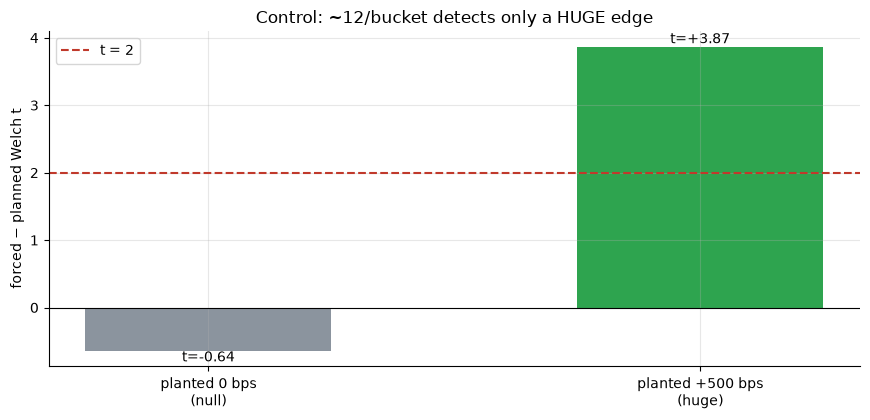

planted +0bps: forced -0.95% (t=-1.51) planned -0.24% diff t=-0.64
planted +500bps: forced +4.05% (t=+6.41) planned -0.24% diff t=+3.87


In [5]:
res = []
for edge in (0.0, 500.0):
    syn = data.synthetic_events(car_bps=edge, seed=391)
    ff, pp = syn['forced_car'], syn['planned_car']
    res.append((edge, ff.mean()*100, st.welch_t(ff), pp.mean()*100, st.welch_t(ff, pp)))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = ['planted 0 bps\n(null)', 'planted +500 bps\n(huge)']
dts = [r[4] for r in res]
ax.bar(labels, dts, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(dts): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('forced − planned Welch t'); ax.set_title('Control: ~12/bucket detects only a HUGE edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,fm,ft,pm,dt in res: print(f'planted {e:+.0f}bps: forced {fm:+.2f}% (t={ft:+.2f}) planned {pm:+.2f}% diff t={dt:+.2f}')

> 💡 In plain words: with **no** real edge the control's forced−planned t is **-0.64** (below 2 — no false positive); only a **+5%/event** edge — enormous — reaches **t = 3.87**. So the machinery is honest, and the real-tape forced−planned t of **0.76** is exactly what an *absent or tiny* edge looks like through a 12-per-bucket keyhole. The sample size is the verdict.

## 5 · The verdict

- **Signal `WEAK`** — a genuine day-0 forced repricing (**+2.0%**, placebo **p = 0.007**), but confined to the un-holdable $[0,0]$ window. Holdable $[0,+2]$: forced **+1.0%** (t = 0.63), forced−planned **+1.5pp** at **t = 0.76** / placebo **p = 0.25**. Literature support + a positive-but-insignificant, window-fragile estimate on a subjective label ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — enter +1 day (the only executable timing): forced **-0.8%** (t = -0.70), net **-0.9%**. The whole move is the announcement instant; there is no post-news drift to capture.
- **Good or bad? `BUSTED`** — the only reliable move is un-catchable; the holdable drift is **zero in both directions**. A window-mining + small-sample illusion.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* forced−planned CAR have to be for a $k$-per-bucket study to detect it at $t=2$? At $k\approx 12$ you'd need a gap several times the one observed; the real signal lives far below the detection floor.

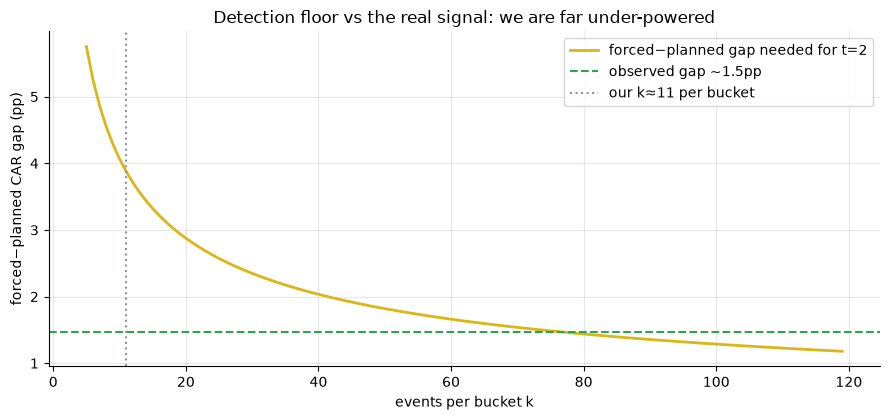

at k≈11 you need ~3.9pp gap for t=2; observed ~1.5pp -> under-powered by ~2.6x


In [6]:
if HAVE_REAL:
    f = PANEL.loc[PANEL['forced'],'car'].to_numpy(); p = PANEL.loc[~PANEL['forced'],'car'].to_numpy()
    sd = np.sqrt(f.var(ddof=1)/len(f) + p.var(ddof=1)/len(p))   # SE of the difference
    obs_diff = (f.mean() - p.mean()); kf = len(f)
else:
    sd = (R['diff_pp']/100)/max(R['diff_t'],1e-9); obs_diff = R['diff_pp']/100; kf = R['n_forced']
ks = np.arange(5, 120)
se_at_k = sd * np.sqrt(kf / ks)            # SE shrinks ~1/sqrt(k); scale from observed k
min_detectable = 2.0 * se_at_k
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='forced−planned gap needed for t=2')
ax.axhline(abs(obs_diff)*100, c=GREEN, ls='--', label=f'observed gap ~{abs(obs_diff)*100:.1f}pp')
ax.axvline(kf, c=GREY, ls=':', label=f'our k≈{kf} per bucket')
ax.set_xlabel('events per bucket k'); ax.set_ylabel('forced−planned CAR gap (pp)')
ax.set_title('Detection floor vs the real signal: we are far under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd*100
print(f'at k≈{kf} you need ~{need:.1f}pp gap for t=2; observed ~{abs(obs_diff)*100:.1f}pp -> under-powered by ~{need/(abs(obs_diff)*100):.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable gap**; the green line is what we see. They don't meet until $k$ is many times larger than the famous-CEO-firing tape will ever deliver. Even granting the lore a *real* couple-of-point gap, you'd need many decades of additional ousters to prove it — and you *still* couldn't trade it, because the move is in the price before the next open. **The rarity and instant-repricing that make the story vivid are exactly what make it untestable and untradable.**

## 7 · Going further

- **The frequent-event mirror.** [Study 249 — Index-Inclusion](../249-index-inclusion/): the same market-model event study on a *frequent* corporate catalyst (S&P additions) — measurable-but-tiny print, opposite end of the power spectrum.
- **A scheduled catalyst.** [Study 228 — Pre-Earnings-Runup](../228-pre-earnings-runup/) and [Study 369 — Earnings-Revision-Momentum](../369-earnings-revision-momentum/) — does a *known* event leave a capturable drift?
- **Better data.** Replace the hardcoded table with a full ExecuComp/BoardEx turnover panel (hundreds of events), add successor-origin (insider/outsider) and prior-performance controls; the error bars tighten, but the day-one timing problem — the move is priced before you can act — does not.

*The reproducible core is offline and deterministic; the event table is an explicit hardcoded, labelled stand-in. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*